# GVD lengths & NLPR filters — JLT Fig. 1/2

Faithful reproduction of the final figures of `ldbp/l-essfm_test.ipynb` (15x80km)
and `ldbp/l-essfm_test2.ipynb` (186 GBaud), for the chosen scenario.

Models are read from `results/<scenario>/lessfm_Ns<ns>/` — trained for **this**
scenario (do not reuse another scenario's coefficients).

In [1]:
import sys, os
_ROOT = os.path.abspath('..') if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
sys.path.insert(0, os.path.join(_ROOT, 'core')); os.chdir(_ROOT)
import numpy as np
import matplotlib.pyplot as plt
from system import build_system, make_bw

SCENARIO = 'scenario_170km_93GBd'
CONFIG   = f'config/{SCENARIO}.ini'
RESDIR   = f'results/{SCENARIO}'
NS       = 5            # number of steps for the single-Ns figures below
S  = build_system(CONFIG)
Lsp = S['Lsp']; Nsp = S['Nsp']
Nsamp_d = S['Nsamp_d']
nl_filter_length = S['nl_filter_length']


## Load a trained model into `length` and `nl_filter`
Reproduces the variables used by the original notebook: `length` (dict of GVD
step lengths) and `nl_filter` (dict of NLPR filters), plus `bw` and `ssfm_opts`.


In [2]:
def load_into_vars(ns):
    p = f'{RESDIR}/lessfm_Ns{ns}/parameters.csv'
    lines = open(p).read().strip().split('\n')
    bw = make_bw(S, ns)
    M = bw.model_steps
    nfl = nl_filter_length
    if len(lines) != M + (M-1)*nfl:
        nfl = (len(lines) - M) // (M - 1)
    length, nl_filter, idx = {}, {}, 0
    for NN in range(M):
        length[NN] = float(lines[idx]); idx += 1
        if NN < M-1:
            nl_filter[NN] = np.array([float(lines[idx+j]) for j in range(nfl)]); idx += nfl
    return length, nl_filter, bw, nfl

length, nl_filter, bw, nfl = load_into_vars(NS)
ssfm_opts = {'StPS': NS}


## Figures 2, 3, 4 — GVD lengths, NLPR filters (time), NLPR response (freq)
*(identical to the original notebook's cell 21)*

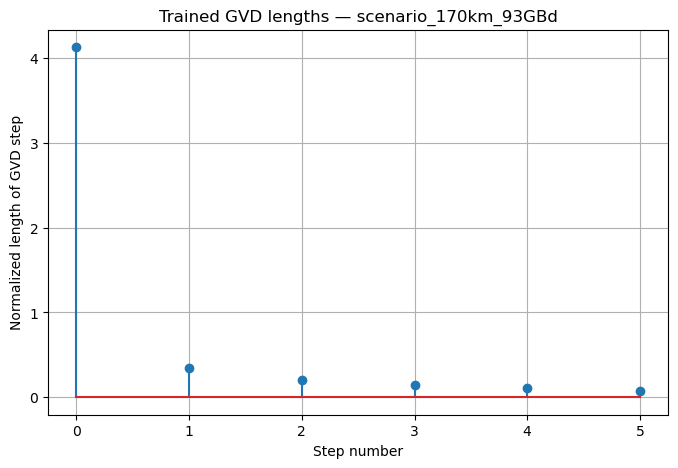

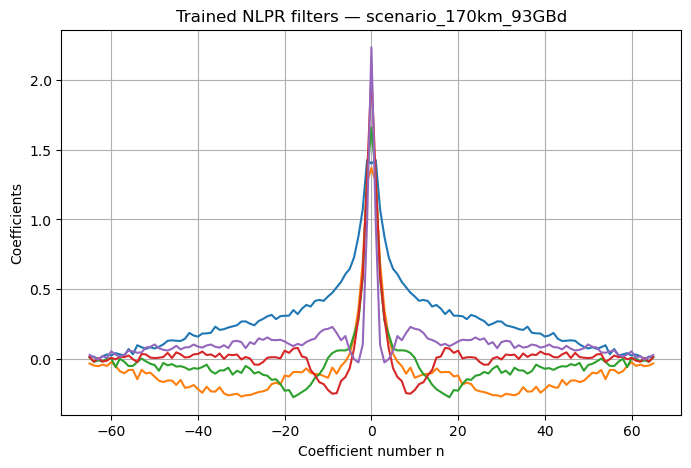

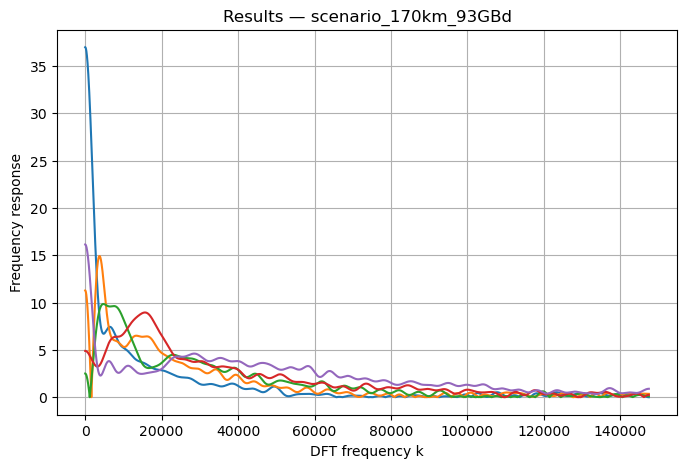

In [3]:
cd_array = np.array(list(length.values()))
#cd_array[0] *= 0.5
#cd_array[-1] *= 0.5

plt.figure(2, figsize=(8, 5))
plt.stem(cd_array)
plt.xlabel('Step number')
plt.ylabel('Normalized length of GVD step')
plt.title(f'Trained GVD lengths — {SCENARIO}')
plt.grid(True)
plt.show()

plt.figure(3, figsize=(8, 5))
nl_time = {}
for NN in range(bw.model_steps-1):
    nl_tmp = nl_filter[NN]
    nl_time[NN] = np.concatenate([np.flip(nl_tmp[1:]), nl_tmp])

    plt.plot(np.arange(-nl_filter_length+1, nl_filter_length), nl_time[NN])
plt.xlabel('Coefficient number n')
plt.ylabel('Coefficients')
plt.title(f'Trained NLPR filters — {SCENARIO}')
plt.grid(True)
plt.show()

plt.figure(4, figsize=(8, 5))
nl_freq = {}
for NN in range(bw.model_steps-1):
    nl_tmp = np.concatenate([nl_time[NN], np.zeros(Nsamp_d-2*nl_filter_length+1)])
    nl_tmp = np.roll(nl_tmp, -nl_filter_length+1)
    nl_freq[NN] = np.fft.rfft(nl_tmp)

    plt.plot(np.abs(nl_freq[NN]))
plt.xlabel('DFT frequency k')
plt.ylabel('Frequency response')
plt.title(f'Results — {SCENARIO}')
plt.grid(True)
plt.show()


## Figure 5 — NLPR positions along the fiber: start (hollow black) vs trained
*(verbatim reproduction of `ldbp/l-essfm_test.ipynb` cell 23)*


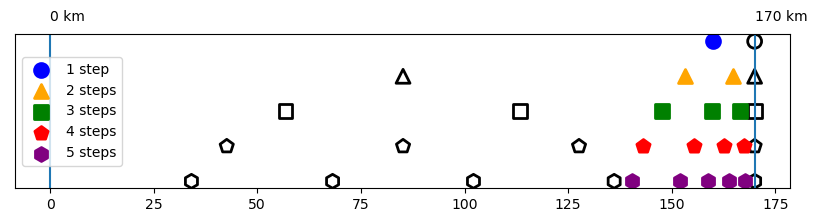

In [4]:
# --- cd_lengths{1..5} (trained) and starting_lengths{1..5} (exp init), in km ---
def _cumkm_trained(ns):
    length, _, bw, _ = load_into_vars(ns)
    cda = np.array(list(length.values()))
    return np.cumsum(cda) * Lsp / ns / 1000
def _cumkm_start(ns):
    alpha_l = S['alpha']/(10*np.log10(np.e))/1000
    def span_steps(Nstep):
        z=[0.0]
        for i in range(1,Nstep):
            z.append(-np.log(1-(i/Nstep)*(1-np.exp(-alpha_l*Lsp)))/alpha_l)
        z.append(Lsp); return np.diff(z)[::-1]
    steps=np.concatenate([span_steps(ns) for _ in range(Nsp)])
    # cumulative boundary positions incl. final L -> Ns+1 points, like the trained array
    return np.concatenate([np.cumsum(steps), [Nsp*Lsp]])/1000
cd_lengths1,cd_lengths2,cd_lengths3,cd_lengths4,cd_lengths5 = [_cumkm_trained(n) for n in (1,2,3,4,5)]
starting_lengths1,starting_lengths2,starting_lengths3,starting_lengths4,starting_lengths5 = [_cumkm_start(n) for n in (1,2,3,4,5)]
L_END = Nsp*Lsp/1000

plt.figure(5, figsize=(10, 2))
y_scatter = np.zeros(1) - 0.1
plt.scatter(starting_lengths1[:-1], y_scatter, marker='o', s=100, color='k', facecolors='none', linewidth=2)
plt.scatter(cd_lengths1[:-1], y_scatter, marker='o', s=100, label='1 step', color='b', linewidth=2)
y_scatter = np.zeros(2) - 0.2
plt.scatter(starting_lengths2[:-1], y_scatter, marker='^', s=100, color='k', facecolors='none', linewidth=2)
plt.scatter(cd_lengths2[:-1], y_scatter, marker='^', s=100, label='2 steps', color='orange', linewidth=2)
y_scatter = np.zeros(3) - 0.3
plt.scatter(starting_lengths3[:-1], y_scatter, marker='s', s=100, color='k', facecolors='none', linewidth=2)
plt.scatter(cd_lengths3[:-1], y_scatter, marker='s', s=100, label='3 steps', color='g', linewidth=2)
y_scatter = np.zeros(4) - 0.4
plt.scatter(starting_lengths4[:-1], y_scatter, marker='p', s=100, color='k', facecolors='none', linewidth=2)
plt.scatter(cd_lengths4[:-1], y_scatter, marker='p', s=100, label='4 steps', color='r', linewidth=2)
y_scatter = np.zeros(5) - 0.5
plt.scatter(starting_lengths5[:-1], y_scatter, marker='h', s=100, color='k', facecolors='none', linewidth=2)
plt.scatter(cd_lengths5[:-1], y_scatter, marker='h', s=100, label='5 steps', color='purple', linewidth=2)
plt.axvline(x=0, color='tab:blue', linestyle='-')
plt.axvline(x=L_END, color='tab:blue', linestyle='-')
plt.text(0, -0.05, '0 km', verticalalignment='bottom')
plt.text(L_END, -0.05, f'{L_END:.0f} km', verticalalignment='bottom')
plt.yticks([])
plt.legend(loc='center left')
plt.show()


## Figure (l-essfm_test2 style) — GVD normalized lengths overlaid
*(reproduction of `ldbp/l-essfm_test2.ipynb` cell 23: `norm_lengths` for Ns=1..5)*

Normalized GVD step lengths = cd_array / (model_steps - 1), overlaid for Ns=1..5.

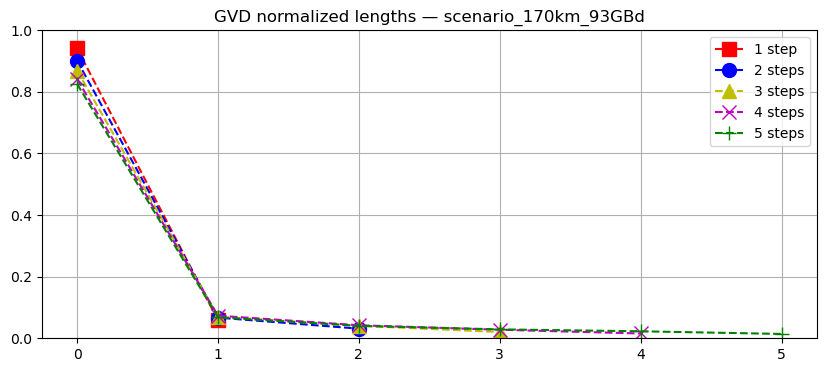

In [5]:
def norm_lengths(ns):
    length, _, bw, _ = load_into_vars(ns)
    cda = np.array(list(length.values()))
    return cda / (bw.model_steps - 1)

nl1 = norm_lengths(1); nl2 = norm_lengths(2); nl3 = norm_lengths(3)
nl4 = norm_lengths(4); nl5 = norm_lengths(5)

plt.rcParams['lines.linewidth'] = 1.5
plt.rcParams['lines.markersize'] = 10
plt.figure(figsize=(10, 4))
plt.plot(nl1, 's--r', label='1 step')
plt.plot(nl2, 'o--b', label='2 steps')
plt.plot(nl3, '^--y', label='3 steps')
plt.plot(nl4, 'x--m', label='4 steps')
plt.plot(nl5, '+--g', label='5 steps')
plt.title(f'GVD normalized lengths — {SCENARIO}')
plt.legend(); plt.ylim([0, 1]); plt.grid(True)
plt.show()
